In [1]:
import cupy as np
import scipy
import cvxpy as cp
import matplotlib.pyplot as plt
import sys

ModuleNotFoundError: No module named 'cupy'

In [3]:
import requests
import tarfile
import shutil

# with open("A.tar.gz", "wb") as file:
#     request = requests.get("https://suitesparse-collection-website.herokuapp.com/MM/FIDAP/ex15.tar.gz")
#     file.write(request.content)
# with tarfile.open("A.tar.gz", "r:gz") as tar:
#     mtx = tar.getmembers()[0]
#     with tar.extractfile(mtx) as file_in:
#       with open("A.mtx", "wb") as file_out:
#         shutil.copyfileobj(file_in, file_out)

# with open("b.tar.gz", "wb") as file:
#     request = requests.get("https://suitesparse-collection-website.herokuapp.com/MM/FIDAP/ex15.tar.gz")
#     file.write(request.content)
# with tarfile.open("b.tar.gz", "r:gz") as tar:
#     mtx = tar.getmembers()[0]
#     with tar.extractfile(mtx) as file_in:
#       with open("b.mtx", "wb") as file_out:
#         shutil.copyfileobj(file_in, file_out)

with open("J.mtx", "wb") as file:
    request = requests.get("https://raw.githubusercontent.com/ORNL/ReSolve/refs/heads/develop/tests/unit/hykkt/SCCGTestMatrices/JC_matrix_ACTIVSg200_AC_00.mtx")
    file.write(request.content)
with open("H.mtx", "wb") as file:
    request = requests.get("https://raw.githubusercontent.com/ORNL/ReSolve/refs/heads/develop/tests/unit/hykkt/SCCGTestMatrices/H_matrix_ACTIVSg200_AC_00.mtx")
    file.write(request.content)
with open("b.mtx", "wb") as file:
    request = requests.get("https://raw.githubusercontent.com/ORNL/ReSolve/refs/heads/develop/tests/unit/hykkt/SCCGTestMatrices/CG_rhs_ACTIVSg200_AC_00.mtx")
    file.write(request.content)

# # read data
# filename = "b.mtx"8
# with open(filename) as f:
#     data = f.readlines()

# # modify
# data[0] = "%%MatrixMarket matrix array real general\n"
# data.insert(1, "%% Generated 13-May-2021\n")

# #write
# with open(filename, 'w') as f:
#     f.writelines(data)

In [54]:
n = A.shape[0]

D = scipy.sparse.diags(1 / np.sqrt(A.diagonal())) # Diagonal scaling matrix
A_bar = D @ A @ D

b_norm = np.linalg.norm(b)
b_bar = 1 / b_norm * (D @ b) #  https://arxiv.org/pdf/1610.03871

B = np.tile(b, (1, k))
B_bar = np.tile(b_bar, (1, k))
X_bar = scipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k]
X = b_norm * D @ X_bar

In [60]:
AX.max()

np.float64(642606606917266.1)

In [62]:
b.max()

np.float64(4086135729.938511)

In [63]:
# This replicates the ReSolve code (but simplifies some logic)
class RandomizedCG:
    def __init__(self, A, b, ITMAX=50):
        self.A = A
        self.b = b
        self.n = self.A.shape[0]

        self.D = scipy.sparse.diags(1 / np.sqrt(self.A.diagonal())) # Diagonal scaling matrix
        self.A_bar = self.D @ self.A @ self.D

        self.b_norm = np.linalg.norm(self.b)
        self.b_bar = 1 / self.b_norm * (self.D @ self.b) #  https://arxiv.org/pdf/1610.03871

        self.rng = np.random.default_rng(seed=1234567)

        self.ITMAX = ITMAX

    def solve(self, k, beta):
        penalty = np.sqrt(beta) * np.ones((1, k))

        eps = sys.float_info.epsilon
        assert(beta * self.n * eps < 0.02)

        B = np.tile(self.b, (1, k))
        B_bar = np.tile(self.b_bar, (1, k))
        X_bar = scipy.stats.ortho_group.rvs(dim=self.n, random_state=self.rng)[:,:k]
        X = self.b_norm * self.D @ X_bar
        # X_bar *= B.std() / (self.A @ X).std()
        # X = self.b_norm * self.D @ X_bar

        TOL = 1e-12

        R_bar = B_bar - self.A_bar @ X_bar
        P = R_bar # Nonzero X_0 => use P = R_bar instead of P = B_bar]

        converged = False
        error = 999999
        error_history = []
        for i in range(self.ITMAX):
            Gamma_i = R_bar.T @ R_bar
            Delta = P.T @ self.A_bar @ P
            Delta_inv = np.linalg.inv(Delta)
            Alpha = Delta_inv @ Gamma_i
            X_bar = X_bar + P @ Alpha
            R_bar = R_bar - self.A_bar @ P @ Alpha

            X = self.b_norm * self.D @ X_bar
            if k == 1:
                x = X
            else:
                # Find optimal linear combination of the columns of X
                AX_with_penalty = np.vstack([self.A @ X, penalty])
                b_with_penalty = np.vstack([self.b, np.sqrt(beta)])
                c, _, _, _ = np.linalg.lstsq(AX_with_penalty, b_with_penalty)
                x = X @ c

            r = self.b - self.A @ x
            # error = np.linalg.norm(r)
            error = np.linalg.norm(r) / self.b_norm
            error_history.append(error)
            print(f"iteration {i}, error {error}")
            if (error < TOL):
                converged = True
                # print(f"Converged in {i + 1} iterations. Error: {min_norm}")
                break

            Gamma_i1 = R_bar.T @ R_bar
            Gamma_i_inv = np.linalg.inv(Gamma_i)
            Beta = Gamma_i_inv @ Gamma_i1
            Gamma_i = Gamma_i1
            P = R_bar + P @ Beta

        if not converged:
            i = -1
            # print("Didn't converge.")

        basis_errors = np.linalg.norm(np.tile(self.b, (1, k)) - A @ X, axis=0)
        # print(f"Error of final linear combination solution: {error}")
        # print(f"Errors of each individual column of X_bar: {np.linalg.norm(basis_errors, axis=0)}")
        return (i, error, basis_errors, error_history)

In [6]:
# Big matrix setup
with open("A.tar.gz", "wb") as file:
    request = requests.get("https://suitesparse-collection-website.herokuapp.com/MM/FIDAP/ex15.tar.gz")
    file.write(request.content)
with tarfile.open("A.tar.gz", "r:gz") as tar:
    mtx = tar.getmembers()[0]
    with tar.extractfile(mtx) as file_in:
      with open("A.mtx", "wb") as file_out:
        shutil.copyfileobj(file_in, file_out)
A = scipy.io.mmread("A.mtx").tocsc()
# b = scipy.io.mmread("b.mtx")
b = np.random.uniform(np.min(A), np.max(A), (A.shape[0], 1))

## Proper code

In [17]:
A = solver.D @ solver.A_bar @ solver.D
norm_A = scipy.sparse.linalg.norm(A)
norm_invA = scipy.sparse.linalg.norm(scipy.sparse.linalg.inv(A))
norm_A*norm_invA

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


np.float64(1.7640533299966168e+23)

iteration 0, error 19507.26720183366
iteration 1, error 12576.704158498027
iteration 2, error 11305.23091090728
iteration 3, error 9949.52357570035
iteration 4, error 7114.237995444459
iteration 5, error 6230.9737429291445
iteration 6, error 4900.329377693293
iteration 7, error 4309.309276768878
iteration 8, error 3736.4924985315333
iteration 9, error 3182.0669491106914
iteration 10, error 2423.348858601873
iteration 11, error 2094.6467717012906
iteration 12, error 1778.6549753957024
iteration 13, error 1505.8559874124112
iteration 14, error 1364.6346231671612
iteration 15, error 1174.9917073500849
iteration 16, error 935.6372040863362
iteration 17, error 829.1378889335848
iteration 18, error 673.0125343543776
iteration 19, error 580.0299732884089
iteration 20, error 469.28579360528965
iteration 21, error 443.4188212815689
iteration 22, error 319.7562197486197
iteration 23, error 267.8509049504791
iteration 24, error 216.99201193200074
iteration 25, error 192.77356733730437
iteration 2

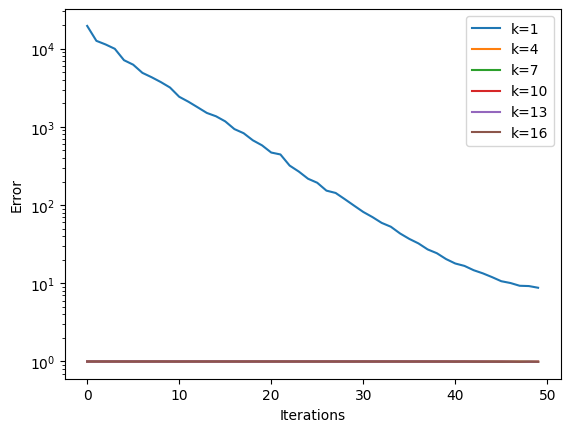

In [64]:
# Run experiments and plot

A = scipy.io.mmread("A.mtx").tocsc()
# b = scipy.io.mmread("b.mtx")
b = np.random.uniform(-np.max(A), np.max(A), (A.shape[0], 1))

# J = scipy.io.mmread("J.mtx").tocsc()
# H = expand_symmetric(scipy.io.mmread("H.mtx")).tocsc()
# A = J @ scipy.sparse.linalg.inv(H) @ J.T
# b = scipy.io.mmread("b.mtx")

MAX_K = 17
INCREMENT = 3

solver = RandomizedCG(A, b, 50)

convergence_iters_a = np.array([])
errors_a = np.array([])
diff_with_best_basis_a = np.array([])
error_history_a = []

# convergence_iters_b = np.array([])
# errors_b = np.array([])
# diff_with_best_basis_b = np.array([])

for k in range(1, MAX_K, INCREMENT):
    convergence_iter_a, error_a, basis_errors_a, error_history_a = solver.solve(k, 1e1)
    convergence_iters_a = np.append(convergence_iters_a, convergence_iter_a)
    errors_a = np.append(errors_a, error_a)
    diff_with_best_basis_a = np.append(diff_with_best_basis_a, np.min(basis_errors_a) - error_a)
    plt.semilogy(np.array(error_history_a), label=f"k={k}")

    # convergence_iter_b, error_b, basis_errors_b = solver.solve(k, 1e10)
    # convergence_iters_b = np.append(convergence_iters_b, convergence_iter_b)
    # errors_b = np.append(errors_b, error_b)
    # diff_with_best_basis_b = np.append(diff_with_best_basis_b, np.min(basis_errors_b) - error_b)

    print(k)

# plt.plot(np.arange(1, MAX_K, INCREMENT), convergence_iters_a)
# plt.plot(np.arange(1, MAX_K, INCREMENT), convergence_iters_b)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()

## Code archive

In [ ]:
def solve_no_preconditioning(A, b, k, TOL):
    n = A.shape[0]
    A_bar = A
    B_bar = np.tile(b, (1, k)) #  https://arxiv.org/pdf/1610.03871
    rng = np.random.default_rng(seed=1234567)
    X_bar = scipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k]
    X_bar *= B_bar.var() / (A_bar@X_bar).var()

    ITMAX = 50

    R = B_bar - A_bar @ X_bar
    P = R # Nonzero X_0 => use P = R instead of P = B_bar]

    converged = False
    i = 0
    for i in range(ITMAX):
        Gamma_i = R.T @ R
        Delta = P.T @ A_bar @ P
        Delta_inv = np.linalg.inv(Delta)
        Alpha = Delta_inv @ Gamma_i
        X_bar = X_bar + P @ Alpha
        R = R - A_bar @ P @ Alpha

        R_norms = np.linalg.norm(R, axis=0)
        min_norm = np.min(R_norms)
        # print(min_norm)
        if (min_norm < TOL):
            converged = True
            # print(f"Converged in {i + 1} iterations. Error: {min_norm}")
            break

        Gamma_i1 = R.T @ R
        Gamma_i_inv = np.linalg.inv(Gamma_i)
        Beta = Gamma_i_inv @ Gamma_i1
        Gamma_i = Gamma_i1
        P = R + P @ Beta

    X = X_bar

    if k == 1:
        x = X
    else:
        # Find optimal linear combination of the columns of X
        c = cp.Variable((k, 1))
        objective = cp.Minimize(cp.sum_squares(b - A @ X @ c))
        constraints = [cp.sum(c) == 1, c >= 0]
        prob = cp.Problem(objective, constraints)
        result = prob.solve()
        x = X @ c.value
    if not converged:
        # print("Didn't converge.")
        return (-i, error, basis_errors)
    error = np.linalg.norm(b - A @ x)
    basis_errors = np.tile(b, (1, k)) - A@X
    # print(f"Error of final linear combination solution: {error}")
    # print(f"Errors of each individual column of X_bar: {np.linalg.norm(basis_errors, axis=0)}")
    return (i, error, basis_errors)

In [ ]:
# This replicates the ReSolve code (but simplifies some logic)

J = scipy.io.mmread("J.mtx").tocsc()
H = scipy.io.mmread("H.mtx").tocsc()
b = scipy.io.mmread("b.mtx")
A = J @ scipy.sparse.linalg.inv(H) @ J.T

k = 10
n = A.shape[0]

B = np.tile(b, (1, k)) # Duplicate b across columns
rng = np.random.default_rng(seed=12344567)
X = scipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k]
X *= B.var() / (A@X).var()

ITMAX = 30
TOL = 1e-12

R = B
S = B
W = B

R = R - A @ X
P = R # Nonzero X_0 => use P = R instead of P = B
Gamma_i = R.T @ R

W = A @ R
Delta = W.T @ R
Delta_inv = np.linalg.inv(Delta)
Alpha = Delta_inv @ Gamma_i
Beta = np.zeros((k, k))

for i in range(ITMAX):
    P = R + P @ Beta
    S = W + S @ Beta
    X = X + P @ Alpha
    R = R - S @ Alpha
    Gamma_i1 = R.T @ R

    R_norms = np.linalg.norm(R, axis=0)
    min_norm = np.min(R_norms)
    print(min_norm)
    if (min_norm < TOL):
        print(f"Converged in {i + 1} iterations. Error: {min_norm}")
        break

    W = A @ R

    Delta = W.T @ R
    Gamma_i_inv = np.linalg.inv(Gamma_i)
    Beta = Gamma_i_inv @ Gamma_i1
    Gamma_i = Gamma_i1
    Alpha = np.linalg.inv(Delta - Gamma_i @ np.linalg.inv(Alpha) @ Beta) @ Gamma_i

347.41562208709894
60.3544132052677
10.166323824267689
13.007314228045574
1.0489538463202757
0.03522290543824726
0.0008947084724032891
1.943935175351477e-05
2.7198897654871205e-07
3.3504992483092636e-09
1.323457250304462e-09
7.896446262595817e-11
3.5543994203321826e-12
1.7623180285320826e-12
1.544558133390723e-13
Converged in 15 iterations. Error: 1.544558133390723e-13


In [ ]:
# This implements the textbook CG algorithm

J = scipy.io.mmread("J.mtx").tocsc()
H = scipy.io.mmread("H.mtx").tocsc()
b = scipy.io.mmread("b.mtx")
A = J @ scipy.sparse.linalg.inv(H) @ J.T

n = A.shape[0]
k = 2

rng = np.random.default_rng()
X = scipy.stats.ortho_group.rvs(dim=n, random_state=rng)[:,:k]
B = np.tile(b, (1, k)) # Duplicate b across columns

ITMAX = 1
TOL = 1e-6

R = B - A @ X
P = R
for i in range(ITMAX):
    Gamma_i = R.T @ R
    Delta = P.T @ A @ P
    Delta_inv = np.linalg.inv(Delta)
    Alpha = Delta_inv @ Gamma_i
    X = X + P @ Alpha
    R = R - A @ P @ Alpha

    R_norms = np.linalg.norm(R, axis=0)
    min_norm = np.min(R_norms)
    print(X)
    if (np.min(R_norms) < TOL):
        print(f"Converged. Error: {np.min(R_norms)}")
        break
    Gamma_i1 = R.T @ R
    Gamma_i_inv = np.linalg.inv(Gamma_i)
    Beta = Gamma_i_inv @ Gamma_i1
    Gamma_i = Gamma_i1
    P = R + P @ Beta


